In [95]:
from pathlib import Path
import matplotlib.pyplot as plt
import tifffile as tifff
import numpy as np
import sys
import itk
#rami2d is not yet a python package, the lines below work to import it as a module and its components
rami2d_module_dir = Path("../src").resolve()#point manually to the folder with the module
if str(rami2d_module_dir ) not in sys.path:
    sys.path.insert(0,str(rami2d_module_dir))
from rami2d.register import apply_transform

### **Example_01:** registration of H&E and IMF images.
Run the register.py script to register the images inside the folder imf_and_he ("../data/samples/imf_and_he/").
We will take the multiplexed image as the fixed image and the H&E as the moving image.

The script below uses the exclamation mark (!) to execute the register.py as a shell command inside this jupyter notebook. The instructions to generally execute this in the command prompt is found in https://github.com/VictorDidier/RAMI2D/tree/main?tab=readme-ov-file#installation-and-usage

In [ ]:
#Load data
example_dir=Path("../data/samples/imf_and_he/")
fixed_img_path = example_dir/"multiplexed.ome.tif"
moving_img_path = example_dir/"HE.ome.tif"
results_dir = example_dir/"results" 

# Change directory 
%cd {rami2d_module_dir}

# Run command in a subshell using the escape command (!)
!python -m rami2d.register -mov {moving_img_path.as_posix()} -imov h -mpp-mov 0.27 -fix {fixed_img_path.as_posix()} -ifix 0 -mpp-fix 0.21 -o {results_dir.as_posix()} -mpp-reg 1 -mpp-key 3 -a

The output of the register.py script is found in the results_dir.  The output is the registered moving image and a qc-folder containing three directories: fullres_trf, keypoints and refchns.  The fullres_trf has all the transformations applied to the moving image in order to be registered.  These transformations can be later used to register other images associated to the original moving data (check Example_02).

### Visualize the registration results.
Display the original moving image(H&E), the fixed image(just DAPI channel), and the registered moving image.

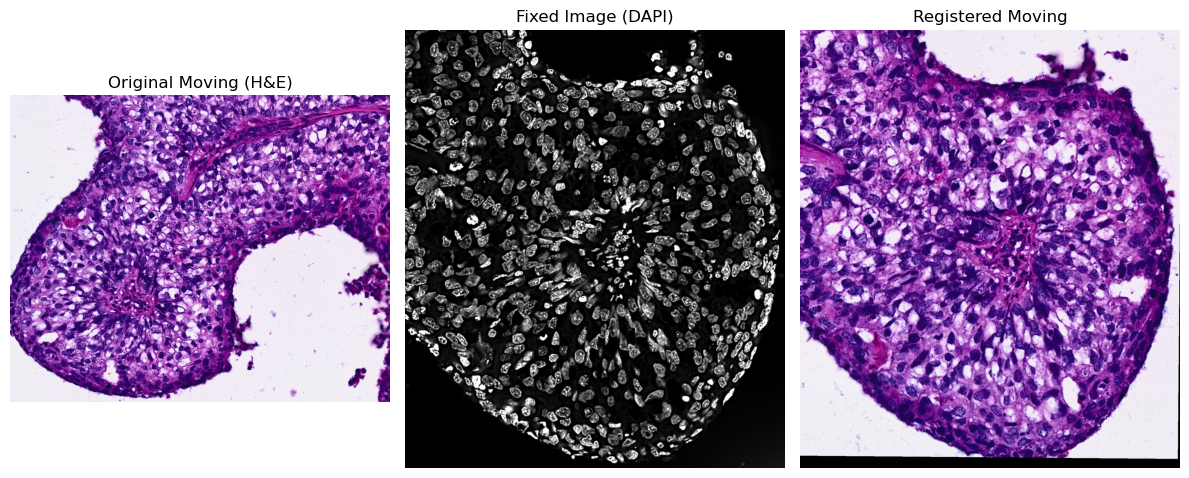

In [97]:

# Load fixed and moving images
fix_img=tifff.imread(fixed_img_path,series=0,level=0,key=0)
mov_img_original=tifff.imread(moving_img_path,series=0,level=0)
# Load registered image (i.e. output of Example_01)
mov_img_registered=tifff.imread(results_dir/"HE_registered.ome.tif",series=0,level=0)

# Create plot
vmin_fix, vmax_fix = np.percentile(fix_img, (2, 98))
# Create 1x3 grid
fig, axes = plt.subplots(1, 3, figsize=(12, 8))

# Column 1: original moving image
axes[0].imshow(mov_img_original, cmap='gray')
axes[0].set_title("Original Moving (H&E)")
axes[0].axis('off')

# Column 2: fixed image
axes[1].imshow(fix_img, cmap='gray',vmin=vmin_fix, vmax=vmax_fix)
axes[1].set_title("Fixed Image (DAPI)")
axes[1].axis('off')
# Column 3: registered moving image
axes[2].imshow(mov_img_registered, cmap='gray')
axes[2].set_title("Registered Moving")
axes[2].axis('off')
plt.tight_layout()
plt.show()

### **Example_02:** transform segmentation masks or annotations made on the moving image so they are also registered to the fixed image.

First fetch the transformation files (trf_files) and use them to create a transformation_map

In [98]:
# Get all the txt files from the transformation folder
trf_dir=results_dir/"qc_reg"/"fullres_trf"
trf_files=sorted(list(trf_dir.glob("*")))
# Create a parameter map with the transformation files
transformation_map=itk.ParameterObject.New()
for f in trf_files:
    transformation_map.AddParameterFile(str(f))
#Uncomment the line below for displaying the transformation maps
#print(transformation_map)

Apply the transformation_map to the annotations done on the H&E image ("../data/samples/imf_and_he/annotations.tif")

In [99]:
annotations=example_dir / "annotations.tif"
outfile=example_dir / "annotations_registered.tif"
annot_reg=apply_transform(annotations,transformation_map,0.21,in_mpp=0.27,is_label=True)
# The output of apply_transform is a generator, hence we use below the function next to load the image in memory
tifff.imwrite(outfile,next(annot_reg),photometric="minisblack")

### Vizualize registered annotations

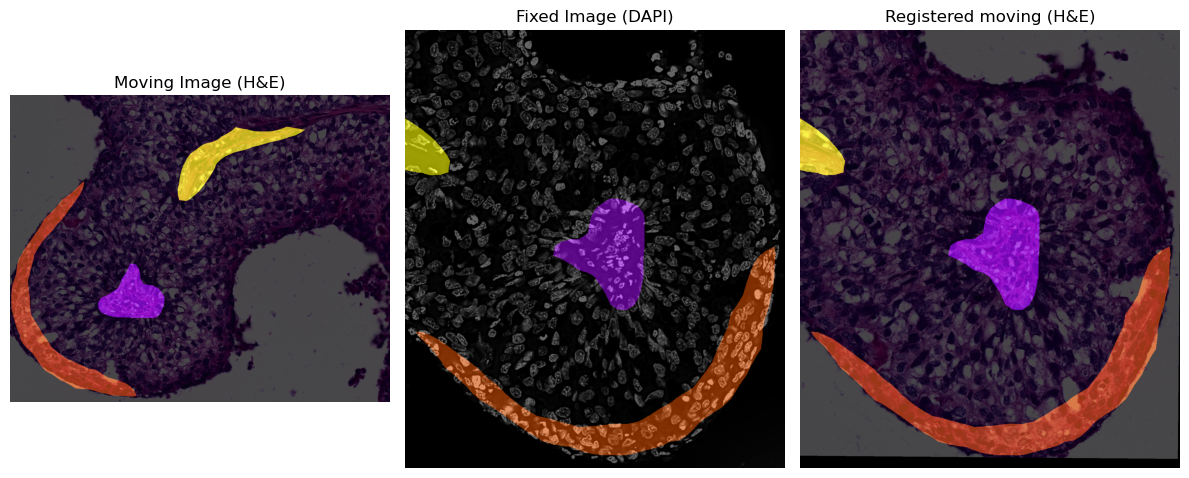

In [100]:

# Load annotations
annotations_original=tifff.imread(annotations)
annotations_reg=tifff.imread(outfile)

# Create plot
fig, axes = plt.subplots(1, 3, figsize=(12, 8))

# Column 1: original moving with annotations

axes[0].imshow(annotations_original, cmap='gnuplot')
axes[0].imshow(mov_img_original,alpha=0.3)
axes[0].set_title("Moving Image (H&E)")
axes[0].axis('off')

# Column 2: original moving image+annotations
axes[1].imshow(fix_img, cmap='gray', vmin=vmin_fix, vmax=vmax_fix)
axes[1].imshow(annotations_reg, cmap='gnuplot',alpha=0.6)
axes[1].set_title("Fixed Image (DAPI)")
axes[1].axis('off')

# Column 3: overlay = fixed + registered moving
axes[2].imshow(annotations_reg, cmap='gnuplot')
axes[2].imshow(mov_img_registered,alpha=0.3)
axes[2].set_title("Registered moving (H&E)")
axes[2].axis('off')

plt.tight_layout()
plt.show()